In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import probjax.stats as stats
from probjax.stats.continuous import pareto, truncnorm
from probjax.stats.transformed import transformed

device = jax.devices("cpu")[0]
jax.default_device(device)


import matplotlib.pyplot as plt

key = jax.random.PRNGKey(0)

# Distributions

Just testing some of the distributions

## Continous Distributions

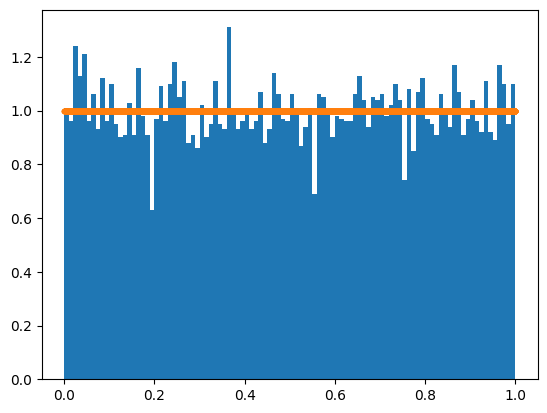

In [3]:
p = stats.uniform(low=0., high=1.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


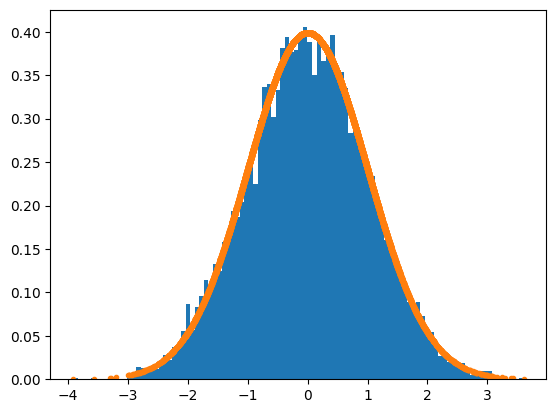

In [4]:
p = stats.norm(0.,1.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


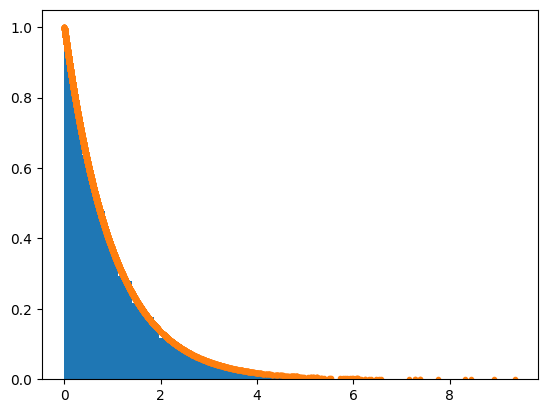

In [5]:
p = stats.gamma(1.,1.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


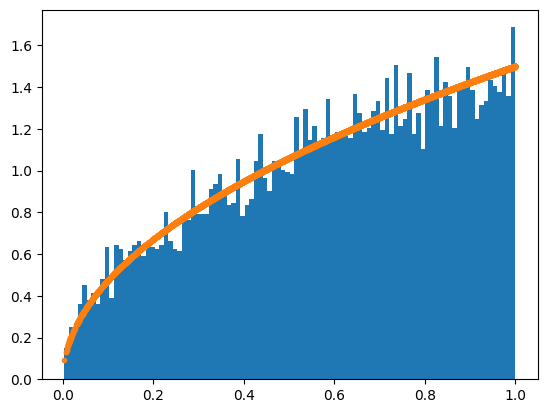

In [6]:
p = stats.beta(1.5,1.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


Array(True, dtype=bool)

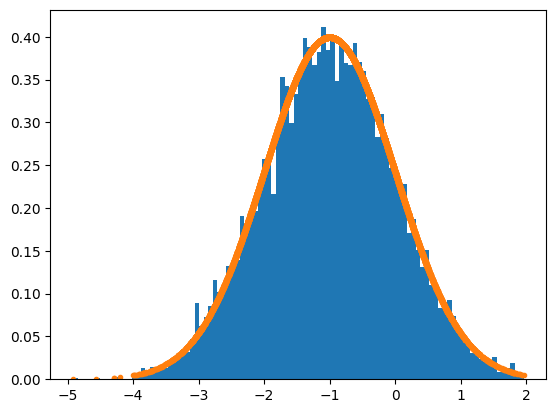

In [7]:
p = truncnorm(loc=-1., scale=1., a=-100., b=2.)
samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
jnp.isfinite(log_prob).all()

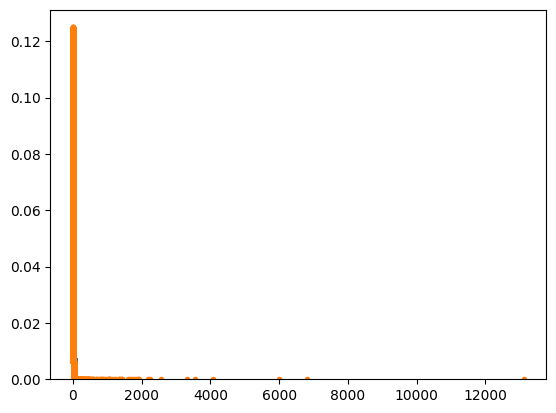

In [8]:
p = pareto(b=2., alpha=1.)
samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

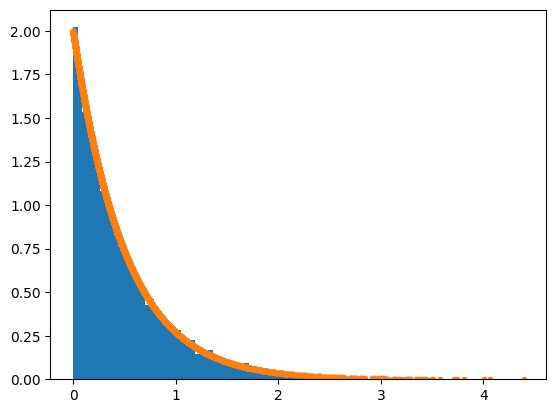

In [9]:
p = stats.expon(2.)
samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

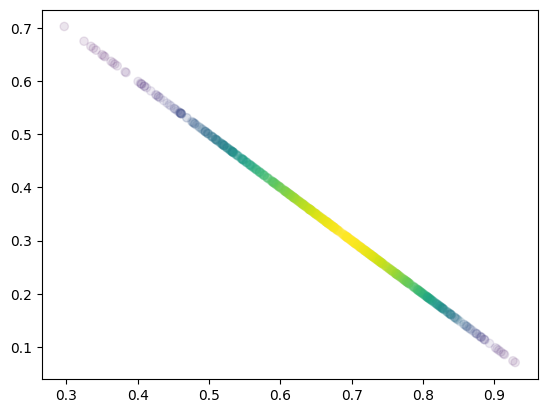

In [10]:
p = stats.dirichlet(jnp.array([10., 5.]))
samples = p.rvs(key, shape=(1000,))

log_prob = p.logpdf(samples)

plt.scatter(samples[:,0], samples[:,1], c=jnp.exp(log_prob), cmap="viridis", alpha=0.1)


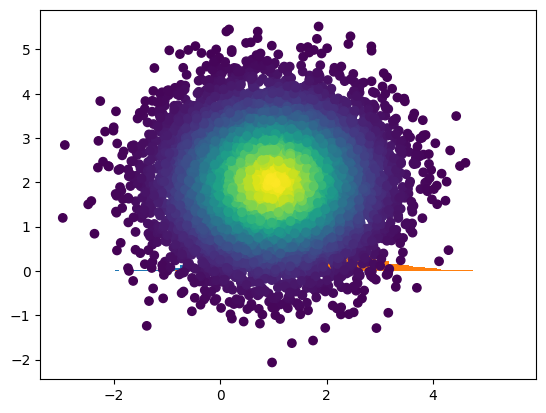

In [11]:
p = stats.multivariate_normal(jnp.array([1.,2.]), jnp.eye(2))
samples = p.rvs(key, shape=(10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.logpdf(samples)
plt.scatter(samples[:,0], samples[:,1], c=jnp.exp(log_prob), cmap="viridis")


## Discrete

(0.0, 1.0)

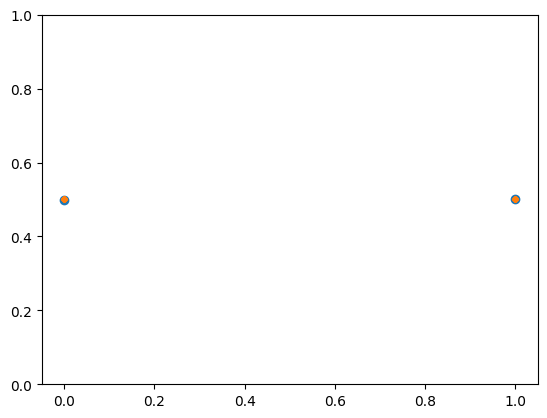

In [12]:
p = stats.bernoulli(jnp.array([0.5]))
samples = p.rvs(key, shape=(100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.logpmf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

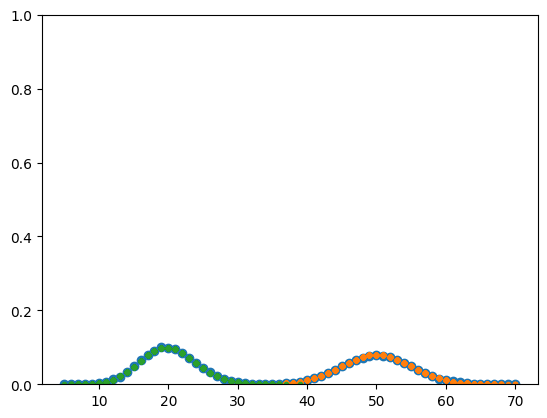

In [13]:
p = stats.binomial(jnp.array([100, 100]), jnp.array([0.5, 0.2]))
samples = p.rvs(key, shape=(100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.logpmf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

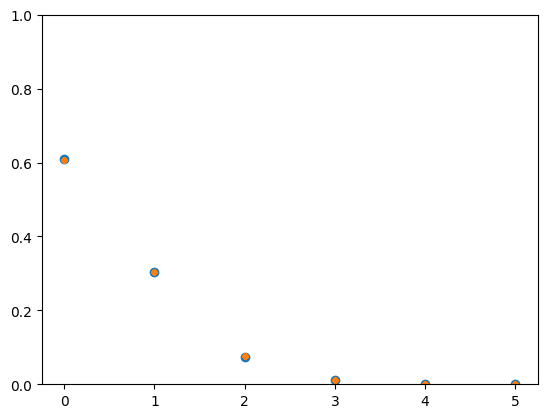

In [14]:
p = stats.poisson(jnp.array([0.5]))
samples = p.rvs(key, shape=(100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.logpmf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

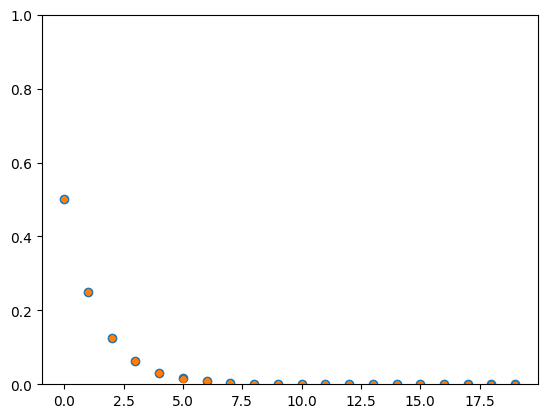

In [15]:
p = stats.geometric(jnp.array([0.5]))
samples = p.rvs(key, shape=(1000000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/1000000, "o")
log_prob = p.logpmf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

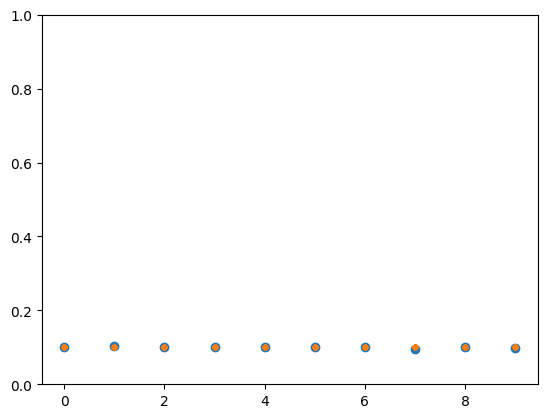

In [16]:
p = stats.categorical(jnp.ones((10))/10)
samples = p.rvs(key, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.logpmf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

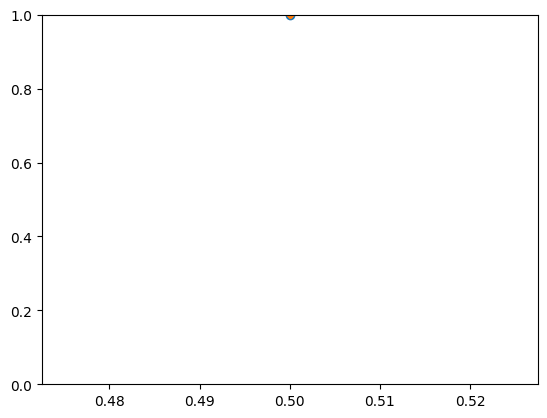

In [17]:
p = stats.dirac(jnp.array([0.5]))
samples = p.rvs(key, shape=(100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.logpmf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

In [18]:
p = stats.empirical(jnp.array([0.2, 0.3]))
samples = p.rvs(key, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.logpmf(samples)
plt.plot(samples, jnp.exp(log_prob), ".", color="C1")
plt.ylim(0,1)

AttributeError: 'NoneType' object has no attribute 'shape'

# Independent

[2] []
(10000, 2)


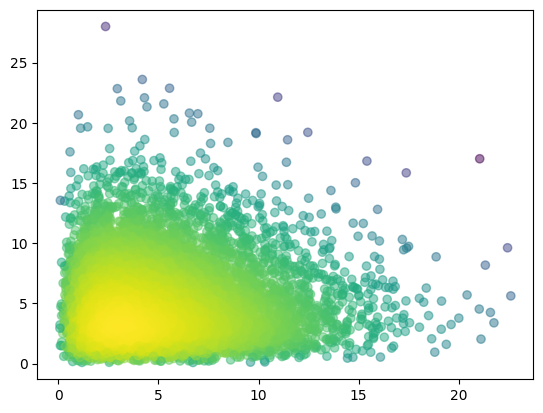

In [ ]:
p1 = stats.chi2(5, jnp.zeros((2,)), jnp.ones((2,)))

p = stats.independent(p1, reinterpreted_batch_ndims=1)

samples = p.rvs(key, shape=(10000,))
log_prob = p.logpdf(samples)

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=log_prob)

In [ ]:
log_prob.shape

(10000,)

In [ ]:
p = stats.independent(*[p1, p2], reinterpreted_batch_ndims=0)

In [ ]:
p.event_shape

(2,)

[2] []
() (2,)
(10000, 2)
[(10000, 1, 1), (10000, 1, 1)]
(10000, 1)
(10000, 2)


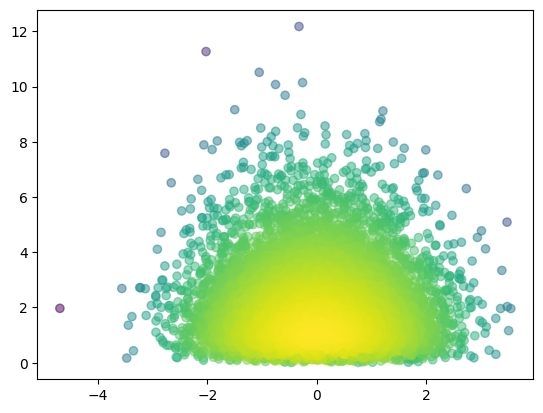

In [ ]:
p1 = stats.norm(jnp.zeros((1,)), jnp.ones((1,)))
p2 = stats.gamma(jnp.ones((1,))*2, jnp.ones((1,)))

p = stats.independent(*[p1, p2], reinterpreted_batch_ndims=1)
print(p1.event_shape, p.event_shape)

samples = p.rvs(key, shape=(10000,))
print(samples.shape)
log_prob = p.logpdf(samples)

print(log_prob.shape)
print(samples.shape)
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=log_prob)

In [ ]:
p1 = stats.multivariate_normal(jnp.zeros((2,)), jnp.eye(2))
p2 = stats.independent(stats.gamma(jnp.ones((1,))*2, jnp.ones((1,))), reinterpreted_batch_ndims=1)


[1] []


In [ ]:
base_dist = [p1, p2]

In [ ]:
p1 = stats.multivariate_normal(jnp.zeros((2,)), jnp.eye(2))
p2 = stats.independent(stats.gamma(jnp.ones((1,))*2, jnp.ones((1,))), reinterpreted_batch_ndims=1)


[1] []


In [ ]:
p1.event_shape, p2.event_shape

((2,), (1,))

In [ ]:
p2 = stats.independent(stats.gamma(jnp.ones((1,))*2, jnp.ones((1,))), reinterpreted_batch_ndims=1)

[1] []


In [ ]:
p2.logpdf(p2.rvs(key, shape=(1000,))).shape

(1000, 1)

In [ ]:
p.batch_shape, p.event_shape

((), (2,))

In [ ]:
p.batch_shape, p.event_shape

((), (2,))

[1] []
[] [3]
[(10000, 1), (10000, 1)]


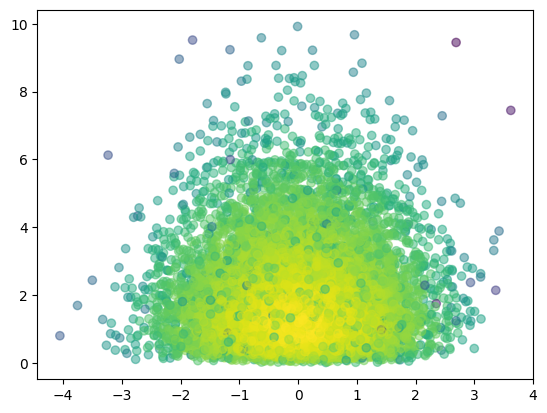

In [ ]:
p1 = stats.multivariate_normal(jnp.zeros((2,)), jnp.eye(2))
p2 = stats.independent(stats.gamma(jnp.ones((1,))*2, jnp.ones((1,))), reinterpreted_batch_ndims=1)

p = stats.independent(*[p1, p2], reinterpreted_batch_ndims=1)

samples = p.rvs(key, shape=(10000,))
log_prob = p.logpdf(samples)

# print(samples.shape)
# print(log_prob.shape)
plt.scatter(samples[:,0], samples[:,2], alpha=0.5, c=log_prob)

In [ ]:
p1 = stats.beta(jnp.array([1.5]), jnp.array([1.5]))
p2 = stats.laplace(jnp.zeros((1,)), jnp.ones((1,)))

p = stats.independent(*[p1, p2], reinterpreted_batch_ndims=1)

[2] []


In [ ]:
samples = p.rvs(key, shape=(10000,))

In [ ]:
p.logpdf(samples).shape

[(10000, 1, 1), (10000, 1, 1)]


(10000,)

In [ ]:
samples.shape

(10000, 3)

In [ ]:
p.event_shape

(2,)

# Mixture

In [ ]:
p = stats.independent(*[p1, p2], reinterpreted_batch_ndims=0)

[2] [4]


In [ ]:
p1.batch_shape, p2.batch_shape

((), ())

In [ ]:
p1.event_shape, p2.event_shape

((2,), (2,))

In [ ]:
p.batch_shape, p.event_shape

((2,), (2,))

In [ ]:
samples = p.rvs(key, shape=(10000,))
log_prob = p.logpdf(samples)


(10000, 2)


In [ ]:
log_prob.shape

(10000, 2, 1)

In [ ]:
samples.shape

(10000, 2, 2)

In [ ]:
log_prob.shape

(10000, 2)

In [ ]:
log_prob.shape

(10000, 2)

In [ ]:
samples.shape

(10000, 2, 2)

In [ ]:
p = stats.independent(*[p1, p2], reinterpreted_batch_ndims=0)

[2] [4]


In [ ]:
p.batch_shape, p.event_shape

((2,), (2,))

In [ ]:
samples = p.rvs(key, shape=(10000,))

In [ ]:
p.logpdf(samples).shape

(10000, 2)

() (2,)
(10000, 2)
(10000,)


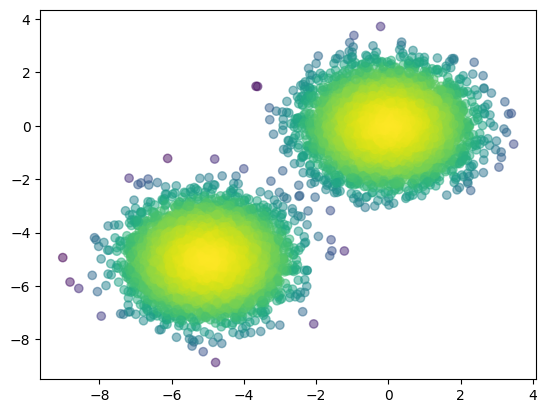

In [ ]:
p1 = stats.multivariate_normal(jnp.array([0.,0.]),jnp.eye(2))
p2 = stats.multivariate_normal(jnp.array([-5., -5]),jnp.eye(2))
p = stats.mixture(jnp.array([0.5,0.5]), [p1,p2])
print(p.batch_shape, p.event_shape)
samples = p.rvs(key, shape=(10000,))
print(samples.shape)
#_ = plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
print(log_prob.shape)
#plt.plot(samples, jnp.exp(log_prob), ".")

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c= log_prob)


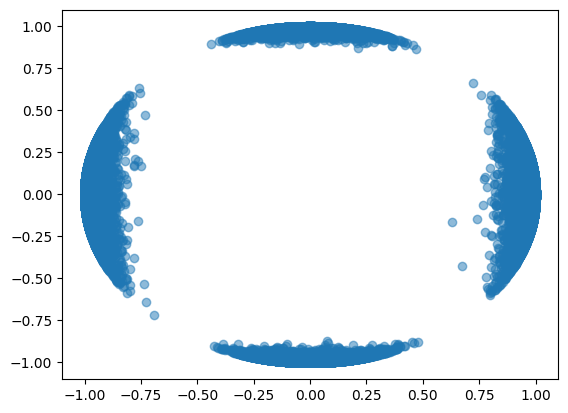

In [77]:
p1 = stats.watson(jnp.array([0.,1.,0.]), jnp.array(40.0))
p2 = stats.watson(jnp.array([1.,0.,0.]), jnp.array(20.0))

p = stats.mixture(jnp.array([0.5,0.5]), [p1,p2])
samples = p.rvs(key, shape=(100000,))

plt.scatter(samples[:,0], samples[:,1], alpha=0.5)

In [79]:
p1.__dict__

{'args': (),
 'kwds': {'mean_direction': Array([0., 1., 0.], dtype=float32),
  'kappa': Array(40., dtype=float32, weak_type=True)},
 'dist': <probjax.stats.continuous.watson.watson_gen at 0x11cb41910>,
 '_batch_shape': (),
 '_event_shape': (3,)}

In [80]:
samples_p1 = p1.rvs(key, shape=(10000,))
stats.watson.fit(samples_p1)

(Array([-0.001,  1.   , -0.   ], dtype=float32), Array(39.736, dtype=float32))

In [157]:
jax.jit(stats.bingham.fit)(samples)

(Array([[-1.   ,  0.003,  0.011],
        [ 0.008, -0.504,  0.864],
        [ 0.008,  0.864,  0.504]], dtype=float32),
 Array([ 2.292, -1.12 , -1.173], dtype=float32))

(Array([[-1.   ,  0.003,  0.011],
       [ 0.008, -0.504,  0.864],
       [ 0.008,  0.864,  0.504]], dtype=float32), Array([ 2.292, -1.12 , -1.173], dtype=float32))


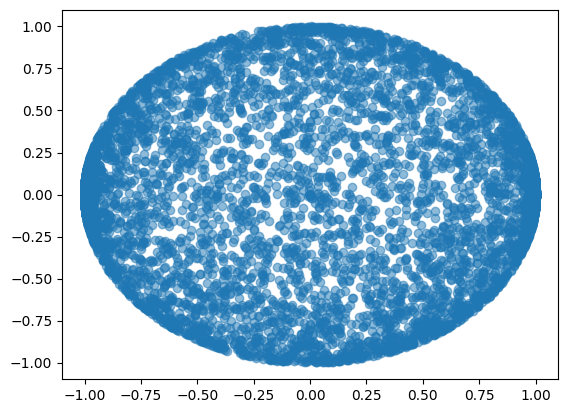

In [162]:
p1 = stats.bingham(jnp.array([[1.,0.,0.],[0.,1.,0.], [0.,0.,0.]]), jnp.array([50.,5., 1.]))
p2 = stats.bingham(jnp.array([[0.,0.,0.],[0.,0.,0.], [0.,0.,1.]]), jnp.array([5.,5., 1.]))
p_mix = stats.mixture(jnp.array([0.5,0.5]), [p1,p2])
samples = p_mix.rvs(key, shape=(10000,))
print(stats.bingham.fit(samples))
p1_new = stats.bingham(*stats.bingham.fit(samples))
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)


In [163]:
p_rec.kwds["components"][0].kwds["orientation"]

Array([[ 1.   ,  0.   ,  0.001],
       [ 0.   , -0.98 ,  0.198],
       [ 0.001, -0.198, -0.98 ]], dtype=float32)

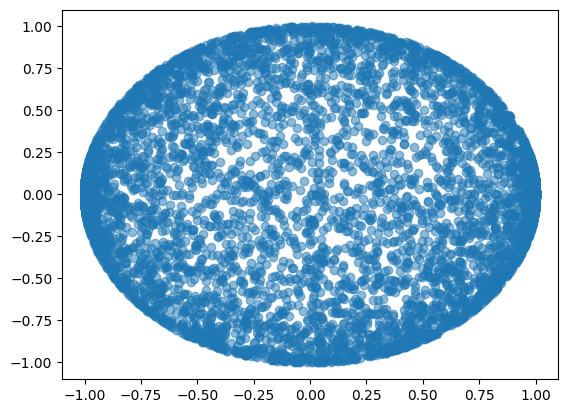

In [164]:
p_rec = stats.mixture(*stats.mixture.fit(samples, [p1, p2]), max_iter=500)
samples_rec = p_rec.rvs(key, shape=(10000,))
plt.scatter(samples_rec[:,0], samples_rec[:,1], alpha=0.5)

In [129]:
stats.bingham.axial_dispersion(*stats.bingham.fit(samples))

Array(0.02, dtype=float32)

In [110]:
p1.mean()

Array([0., 0., 0.], dtype=float32)

In [168]:
jax.jit(stats.watson.fit)(samples)

(Array([-1.   ,  0.008,  0.008], dtype=float32), Array(3.409, dtype=float32))

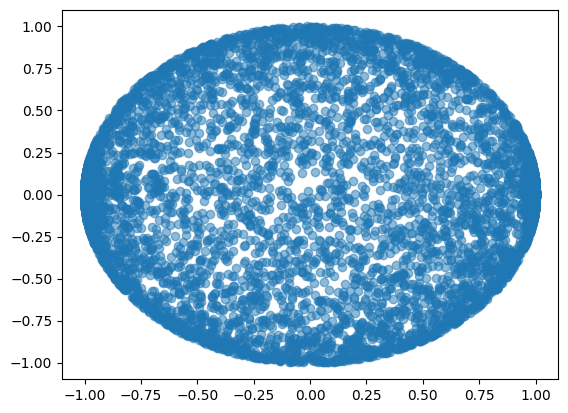

In [170]:

p1 = stats.watson(jnp.array([0.,0.,1.]), jnp.array(10.0))
p2 = stats.watson(jnp.array([1.,0.,0.]), jnp.array(20.0))
new_frac, (new_p1, new_p2) = stats.mixture.fit(samples, [p1,p2], max_iter=500, tol=1e-9)
new_mix = stats.mixture(new_frac, [new_p1, new_p2])
samples_new = new_mix.rvs(key, shape=(10000,))
plt.scatter(samples_new[:,0], samples_new[:,1], alpha=0.5)

In [83]:
new_p2.__dict__

{'args': (),
 'kwds': {'mean_direction': Array([ 1.   , -0.001, -0.   ], dtype=float32),
  'kappa': Array(19.984, dtype=float32)},
 'dist': <probjax.stats.continuous.watson.watson_gen at 0x11cb41910>,
 '_batch_shape': (),
 '_event_shape': (3,)}

In [70]:
new_p2.__dict__

{'args': (),
 'kwds': {'mean_direction': Array([ 1.   , -0.001, -0.   ], dtype=float32),
  'kappa': Array(34.003, dtype=float32)},
 'dist': <probjax.stats.continuous.watson.watson_gen at 0x11cb41910>,
 '_batch_shape': (),
 '_event_shape': (3,)}

In [27]:
new_frac, (new_p1, new_p2) = stats.mixture.fit(samples+1, [p1, p2], max_iter=500)

In [ ]:
new_p1.var()

Array([1.047, 1.005], dtype=float32)

In [ ]:
p1.mean()

Array([0., 0.], dtype=float32)

In [ ]:
p = stats.independent(*[p1, p2], reinterpreted_batch_ndims=0)

In [ ]:
def get_variable_name(obj):
    for name, val in globals().items():
        if val is obj:
            return name
    return None

In [ ]:
get_variable_name(p)

'p'

In [ ]:
p = stats.independent(*[p1, p2], reinterpreted_batch_ndims=0)

[2] []


In [ ]:
p.batch_shape, p.event_shape

((2,), ())

In [ ]:
p.rvs(key, shape=(10000,)).shape

(10000, 2)

In [ ]:
p.logpdf(p.rvs(key, shape=(10000,))).shape

[2] []
() ()
(10000,)
[(10000, 1, 1), (10000, 1, 1)]
(10000,)


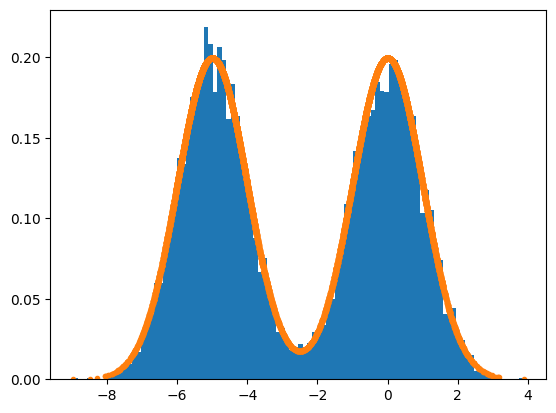

In [ ]:
p1 = stats.norm(jnp.array([0.]),jnp.array([1.]))
p2 = stats.norm(jnp.array([-5.]),jnp.array([1.]))

p = stats.norm(jnp.array([0., -5.]),jnp.array([1., 1.]))

#p = stats.mixture(jnp.array([0.5,0.5]), p)
p = stats.mixture(jnp.array([0.5,0.5]), [p1,p2])
print(p.batch_shape, p.event_shape)
samples = p.rvs(key, shape=(10000,))
print(samples.shape)
_ = plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
print(log_prob.shape)
plt.plot(samples, jnp.exp(log_prob), ".")

# SDEs

In [ ]:
try:
    from probjax.stats.sde import OrnsteinUhlenbeck, VESDE, subVPSDE
except ImportError as err:
    def _sde_not_available(*args, **kwargs):
        raise NotImplementedError(
            "SDE components have not yet been ported to probjax.stats."
        ) from err

    OrnsteinUhlenbeck = _sde_not_available
    VESDE = _sde_not_available
    subVPSDE = _sde_not_available

/tmp/ipykernel_22260/3160051518.py:1: DeprecationWarning: jax.random.PRNGKeyArray is deprecated. Use jax.Array for annotations, and jax.dtypes.issubdtype(arr.dtype, jax.dtypes.prng_key) for runtime detection of typed prng keys (i.e. keys created with jax.random.key).
For more information, see https://jax.readthedocs.io/en/latest/jep/9263-typed-keys.html
  from jax.random import PRNGKeyArray


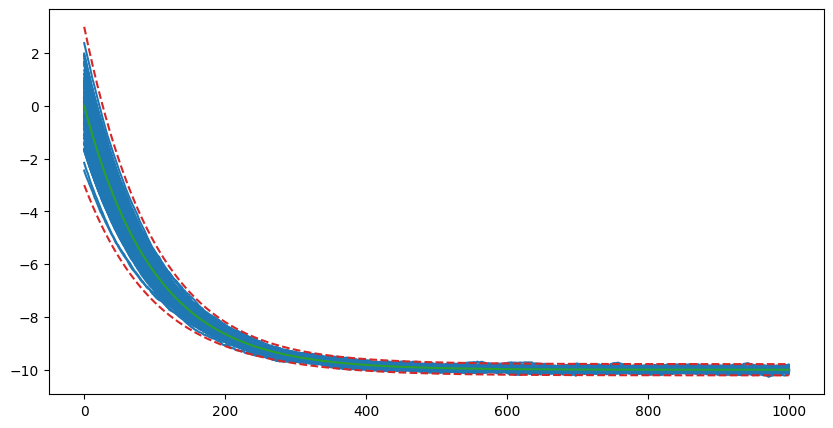

In [ ]:

key = jax.random.PRNGKey(0)
sde = OrnsteinUhlenbeck(1., -10., 0.1)
ts = jnp.linspace(0.0, 10.0, 1000)
x = sde.rsample(key, ts, (100,))
mean = sde.mean(ts)
std = sde.stddev(ts)

plt.figure(figsize=(10, 5))
_ = plt.plot(x.T, color="C0")
_ = plt.plot(mean, color="C2")
_ = plt.plot(mean + 3 * std, color="C3", linestyle="--")
_ = plt.plot(mean - 3 * std, color="C3", linestyle="--")


In [ ]:
sde.diffusion(jnp.array([0.001]), jnp.array([0.00]))

0.1

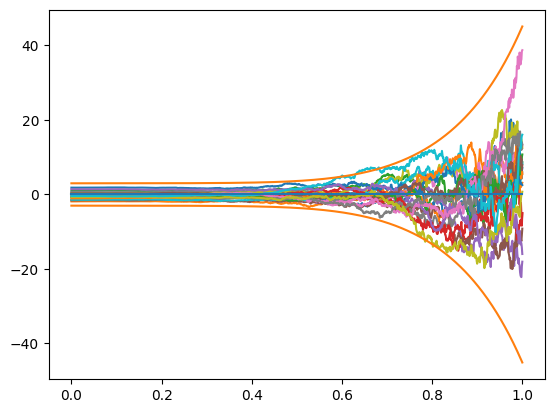

In [ ]:
p0 = stats.norm(jnp.zeros(1), jnp.ones(1))
ts = jnp.linspace(0., 1., 1000)
sde = VESDE(p0, sigma_min=0.03, sigma_max=15.)
mean = sde.mean(ts)
variance = sde.variance(ts)

xs = sde.sample(key, ts,(20,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, mean)
_ = plt.plot(ts, mean + 3*jnp.sqrt(variance), color="C1")
_ = plt.plot(ts, mean - 3*jnp.sqrt(variance), color="C1")

In [ ]:
p0 = stats.norm(jnp.zeros(1), jnp.ones(1)*2)
ts = jnp.linspace(0., 1., 1000)
sde = subVPSDE(p0, beta_min=0.1, beta_max=15.)
mean = sde.mean(ts)
variance = sde.variance(ts)

xs = sde.sample(key, ts,(10,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, mean)
_ = plt.plot(ts, mean + 3*jnp.sqrt(variance), color="C1")
_ = plt.plot(ts, mean - 3*jnp.sqrt(variance), color="C1")

In [ ]:
def output_scale_fn(t, x):
    scale = jnp.sqrt(jnp.sum(sde.marginal_variance(t[..., None], x0=jnp.ones_like(x)), -1))
    return 1/scale[..., None] * x

In [ ]:
float(sde.marginal_variance(jnp.array([1e-5]), x0=jnp.ones((1,))))

/tmp/ipykernel_24688/1139090748.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future.
  float(sde.marginal_variance(jnp.array([1e-5]), x0=jnp.ones((1,))))


1.0728836059570312e-06

In [ ]:
def weight_fn(t):
    t = t.reshape(-1, 1)
    return jnp.clip(1-jnp.exp(-0.5 * (sde.beta_max - sde.beta_min) * t**2 - sde.beta_min * t) ,a_min = 1e-4)

In [ ]:
float(weight_fn(jnp.array([1e-5])))

/tmp/ipykernel_24688/3403893814.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future.
  float(weight_fn(jnp.array([1e-5])))


9.999999747378752e-05

# Transformed Distributon

(0.0, 1.0)

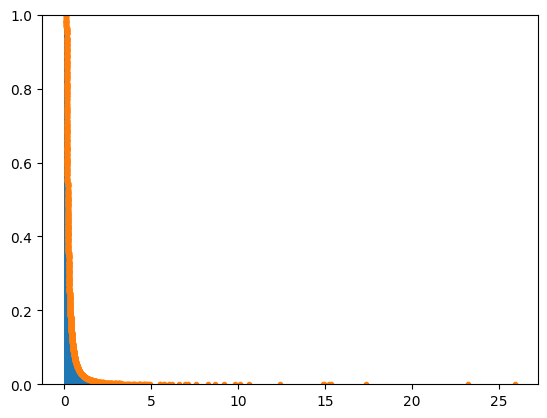

In [ ]:
p0 = stats.norm(0.,1.)
p = transformed(base_dist=p0, bijector=lambda x: jnp.exp(x - 2)**2)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.logpdf(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

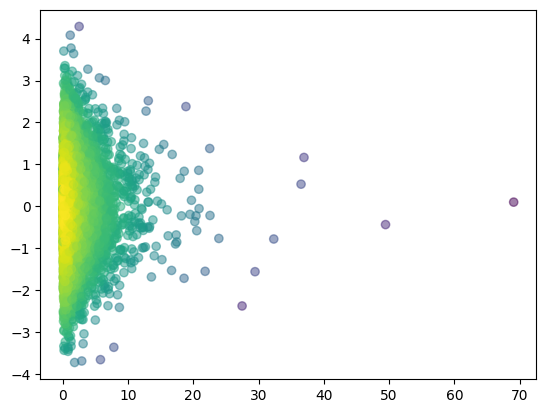

In [ ]:
p0 = stats.independent(stats.norm(jnp.zeros(2), jnp.ones(2)), reinterpreted_batch_ndims=1)

def t(x):
    x = x.at[...,0].set(jnp.exp(x[...,0]))
    return x

p = transformed(base_dist=p0, bijector=t)
samples = p.rvs(key, shape=(10000,))

log_prob = p.logpdf(samples)
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=log_prob)

## Divergences

### KL divergence

In [ ]:
from probjax.stats.divergences import kl_divergence

p0 = stats.norm(0.,1.)
p1 = stats.norm(0.,2.)
dist = kl_divergence(p0,p1)

dist

Array(0.318, dtype=float32, weak_type=True)

### Wassertsein

In [ ]:
from probjax.stats.divergences import wasserstein_distance

p0 = stats.norm(0.,1.)
p1 = stats.norm(0.,2.)

dist = wasserstein_distance(p0,p1)
dist

Array(1., dtype=float32, weak_type=True)